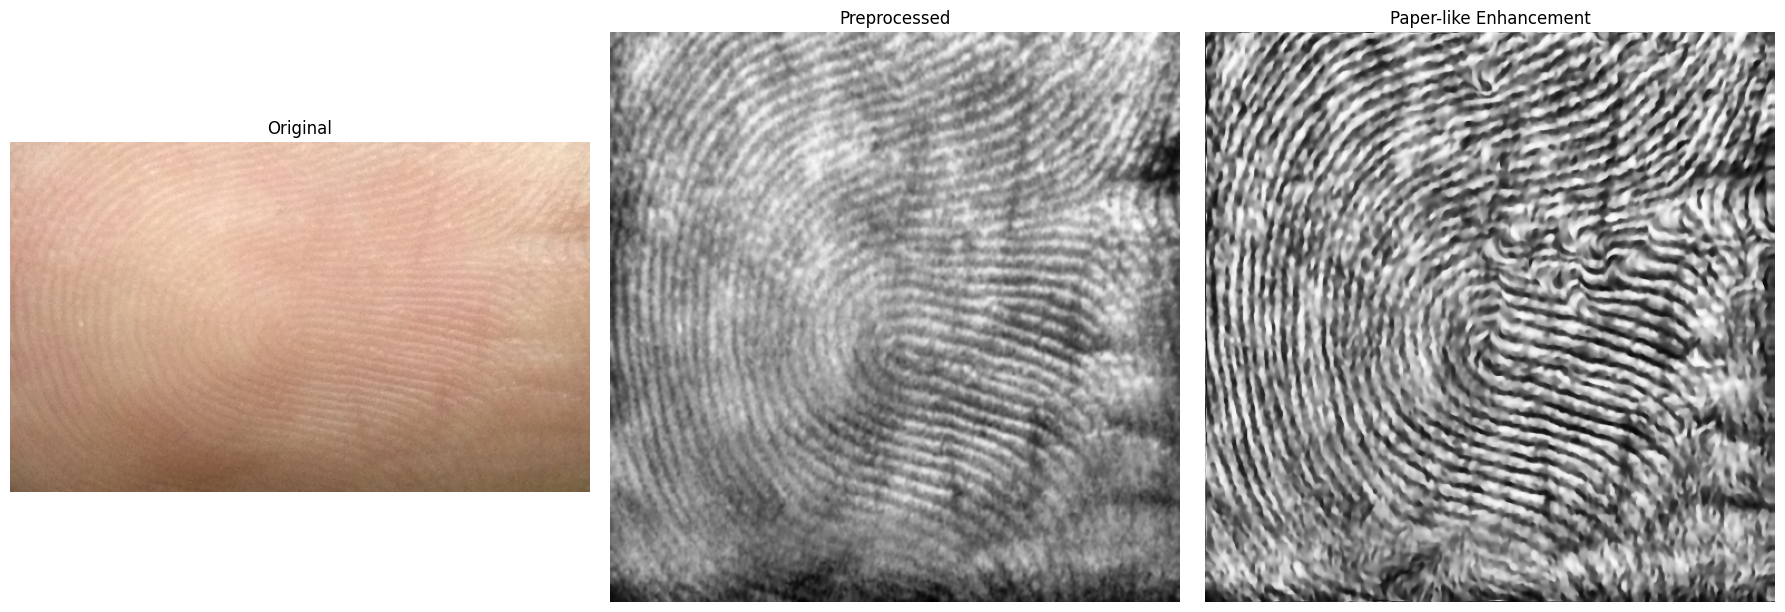

In [25]:
# ============================================================
# ORIENTED DIFFUSION FILTERING (PAPER-LIKE IMPLEMENTATION)
# ============================================================

!pip install opencv-python scipy matplotlib scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

# ============================================================
# LOAD IMAGE
# ============================================================

img = cv2.imread('/content/image.png')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ============================================================
# BETTER GRAYSCALE CONVERSION
# ============================================================

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

gray = l

gray = cv2.resize(gray, (512, 512))

# ============================================================
# PREPROCESSING
# ============================================================

# CLAHE (mild)
clahe = cv2.createCLAHE(
    clipLimit=6.0,
    tileGridSize=(8,8)
)

gray = clahe.apply(gray)

# normalize
gray = cv2.normalize(
    gray,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

# smooth noise
gray = cv2.GaussianBlur(gray, (5,5), 1.0)

gray = gray.astype(np.float32)

# ============================================================
# ORIENTATION FIELD ESTIMATION
# ============================================================

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

# structure tensor smoothing
J11 = gaussian_filter(gx * gx, sigma=7)
J22 = gaussian_filter(gy * gy, sigma=7)
J12 = gaussian_filter(gx * gy, sigma=7)

# orientation field
theta = 0.5 * np.arctan2(
    2 * J12,
    J11 - J22
)

# smooth orientation field
theta = gaussian_filter(theta, sigma=5)

# ============================================================
# ORIENTED DIFFUSION FILTERING
# ============================================================

u = gray.copy()

iterations = 10

for i in range(iterations):

    # gradients
    ux = cv2.Sobel(u, cv2.CV_32F, 1, 0, ksize=3)
    uy = cv2.Sobel(u, cv2.CV_32F, 0, 1, ksize=3)

    # ridge direction
    vx = np.cos(theta)
    vy = np.sin(theta)

    # directional derivative
    u_parallel = ux * vx + uy * vy

    # smooth ONLY along ridge direction
    smooth_parallel = gaussian_filter(
        u_parallel,
        sigma=0.5
    )

    # controlled update
    u = u + 0.08 * smooth_parallel

    # isotropic stabilization
    u = gaussian_filter(u, sigma=0.2)

    # clip
    u = np.clip(u, 0, 255)

# ============================================================
# FINAL CONTRAST ENHANCEMENT
# ============================================================

u = u.astype(np.uint8)

# mild CLAHE
clahe2 = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(16,16)
)

enhanced = clahe2.apply(u)

# ============================================================
# RIDGE CLEANING
# ============================================================

# bilateral filter preserves ridges
enhanced = cv2.bilateralFilter(
    enhanced,
    7,
    50,
    50
)

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Preprocessed")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(enhanced, cmap='gray')
plt.title("Paper-like Enhancement")
plt.axis('off')

plt.tight_layout()
plt.show()

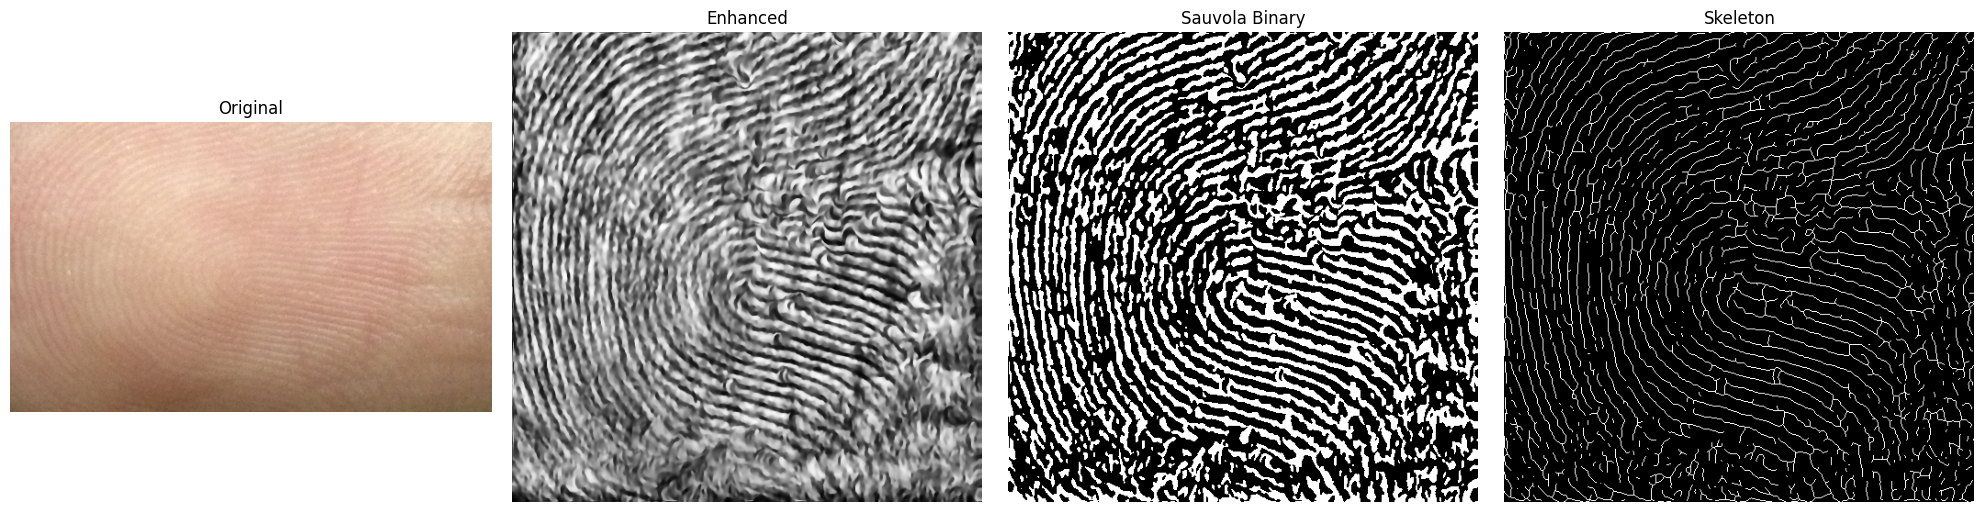

Saved Files:
/content/enhanced_fingerprint.png
/content/binary_sauvola.png
/content/skeleton_fingerprint.png


In [26]:
# ============================================================
# ORIENTED DIFFUSION FILTERING
# + SAUVOLA BINARIZATION
# + SKELETONIZATION
# + SAVE ALL RESULTS
# ============================================================

!pip install opencv-python scipy matplotlib scikit-image -q

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_sauvola
from skimage.morphology import skeletonize

# ============================================================
# LOAD IMAGE
# ============================================================

img = cv2.imread('/content/image.png')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ============================================================
# BETTER GRAYSCALE CONVERSION
# ============================================================

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

gray = l

gray = cv2.resize(gray, (512, 512))

# ============================================================
# PREPROCESSING
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

gray = clahe.apply(gray)

gray = cv2.normalize(
    gray,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

gray = cv2.GaussianBlur(gray, (5,5), 1.0)

gray = gray.astype(np.float32)

# ============================================================
# ORIENTATION FIELD ESTIMATION
# ============================================================

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

J11 = gaussian_filter(gx * gx, sigma=4)
J22 = gaussian_filter(gy * gy, sigma=4)
J12 = gaussian_filter(gx * gy, sigma=4)

theta = 0.5 * np.arctan2(
    2 * J12,
    J11 - J22
)

theta = gaussian_filter(theta, sigma=3)

# ============================================================
# ORIENTED DIFFUSION FILTERING
# ============================================================

u = gray.copy()

iterations = 10

for i in range(iterations):

    ux = cv2.Sobel(u, cv2.CV_32F, 1, 0, ksize=3)
    uy = cv2.Sobel(u, cv2.CV_32F, 0, 1, ksize=3)

    vx = np.cos(theta)
    vy = np.sin(theta)

    u_parallel = ux * vx + uy * vy

    smooth_parallel = gaussian_filter(
        u_parallel,
        sigma=0.5
    )

    u = u + 0.08 * smooth_parallel

    u = np.clip(u, 0, 255)

# ============================================================
# CONTRAST ENHANCEMENT
# ============================================================

u = u.astype(np.uint8)

clahe2 = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(16,16)
)

enhanced = clahe2.apply(u)

# ============================================================
# RIDGE CLEANING
# ============================================================

enhanced = cv2.bilateralFilter(
    enhanced,
    7,
    50,
    50
)

# ============================================================
# SAVE ENHANCED IMAGE
# ============================================================

cv2.imwrite(
    '/content/enhanced_fingerprint.png',
    enhanced
)

# ============================================================
# SAUVOLA ADAPTIVE BINARIZATION
# ============================================================

window_size = 25

thresh_sauvola = threshold_sauvola(
    enhanced,
    window_size=window_size,
    k=0.2
)

binary_sauvola = enhanced > thresh_sauvola

# invert ridges to white
binary_sauvola = np.invert(binary_sauvola)

binary_sauvola = (
    binary_sauvola.astype(np.uint8) * 255
)

# ============================================================
# SAVE BINARIZED IMAGE
# ============================================================

cv2.imwrite(
    '/content/binary_sauvola.png',
    binary_sauvola
)

# ============================================================
# SKELETONIZATION
# ============================================================

binary_bool = binary_sauvola > 0

skeleton = skeletonize(binary_bool)

skeleton = (
    skeleton.astype(np.uint8) * 255
)

# ============================================================
# SAVE SKELETON IMAGE
# ============================================================

cv2.imwrite(
    '/content/skeleton_fingerprint.png',
    skeleton
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola Binary")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved Files:")
print("/content/enhanced_fingerprint.png")
print("/content/binary_sauvola.png")
print("/content/skeleton_fingerprint.png")

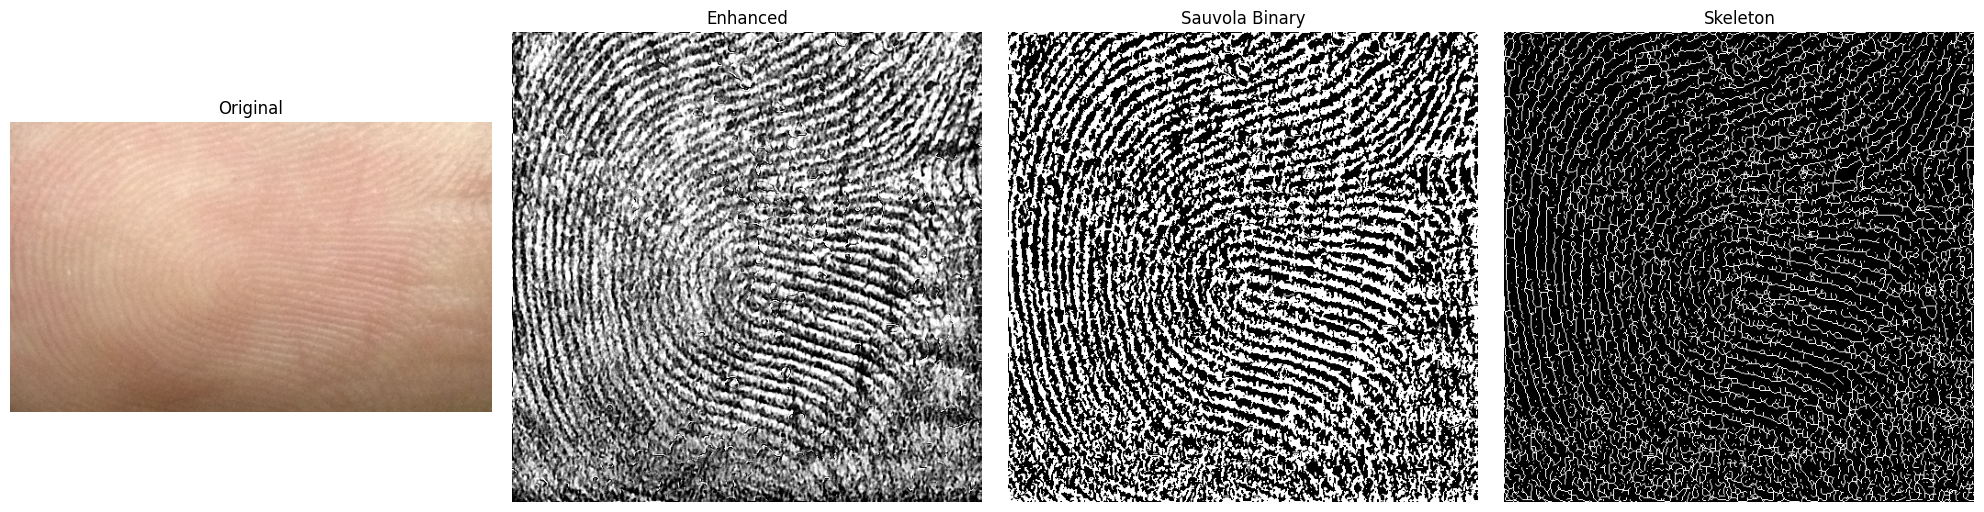

Saved files:
/content/enhanced_output.png
/content/binary_sauvola.png
/content/skeleton_output.png


In [27]:
# ============================================================
# IMPORTS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_sauvola
from skimage.morphology import skeletonize

# ============================================================
# LOAD IMAGE
# ============================================================

img = cv2.imread('/content/image.png')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ============================================================
# GRAYSCALE
# ============================================================

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

gray = cv2.resize(gray, (512, 512))

# ============================================================
# PREPROCESSING
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

gray = clahe.apply(gray)

gray = cv2.normalize(
    gray,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

gray = cv2.GaussianBlur(gray, (5,5), 1)

gray = gray.astype(np.float32)

# ============================================================
# ORIENTATION FIELD ESTIMATION
# ============================================================

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

J11 = gaussian_filter(gx * gx, sigma=4)
J22 = gaussian_filter(gy * gy, sigma=4)
J12 = gaussian_filter(gx * gy, sigma=4)

theta = 0.5 * np.arctan2(
    2 * J12,
    J11 - J22
)

# ============================================================
# COHERENCE
# ============================================================

coherence = np.sqrt(
    (J11 - J22)**2 +
    4 * (J12**2)
)

coherence = coherence / (coherence.max() + 1e-8)

# ============================================================
# ORIENTED DIFFUSION FILTERING
# ============================================================

u = gray.copy()

dt = 0.25
alpha = 0.08
iterations = 10

for i in range(iterations):

    ux = cv2.Sobel(u, cv2.CV_32F, 1, 0, ksize=3)
    uy = cv2.Sobel(u, cv2.CV_32F, 0, 1, ksize=3)

    # ridge direction
    vx = np.cos(theta)
    vy = np.sin(theta)

    # orthogonal direction
    vxp = -vy
    vyp = vx

    # directional derivatives
    u_parallel = ux * vx + uy * vy
    u_perp = ux * vxp + uy * vyp

    # diffusion
    diffusion = alpha * u_parallel
    diffusion += 0.02 * u_perp

    # update
    u = u + dt * diffusion

    # mild stabilization
    u = gaussian_filter(u, sigma=0.2)

    u = np.clip(u, 0, 255)

# ============================================================
# CONTRAST ENHANCEMENT
# ============================================================

u = u.astype(np.uint8)

clahe2 = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(16,16)
)

enhanced = clahe2.apply(u)

# ============================================================
# OPTIONAL SHARPENING
# ============================================================

kernel = np.array([
    [-1,-1,-1],
    [-1, 9,-1],
    [-1,-1,-1]
])

enhanced = cv2.filter2D(
    enhanced,
    -1,
    kernel
)

# ============================================================
# SAVE ENHANCED IMAGE
# ============================================================

cv2.imwrite(
    '/content/enhanced_output.png',
    enhanced
)

# ============================================================
# SAUVOLA BINARIZATION
# ============================================================

window_size = 25

thresh_sauvola = threshold_sauvola(
    enhanced,
    window_size=window_size,
    k=0.2
)

binary_sauvola = enhanced > thresh_sauvola

# invert so ridges become white
binary_sauvola = np.invert(binary_sauvola)

binary_sauvola = (
    binary_sauvola.astype(np.uint8) * 255
)

# ============================================================
# SAVE BINARY IMAGE
# ============================================================

cv2.imwrite(
    '/content/binary_sauvola.png',
    binary_sauvola
)

# ============================================================
# SKELETONIZATION
# ============================================================

binary_bool = binary_sauvola > 0

skeleton = skeletonize(binary_bool)

skeleton = (
    skeleton.astype(np.uint8) * 255
)

# ============================================================
# SAVE SKELETON IMAGE
# ============================================================

cv2.imwrite(
    '/content/skeleton_output.png',
    skeleton
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola Binary")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton")
plt.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# OUTPUT PATHS
# ============================================================

print("Saved files:")
print("/content/enhanced_output.png")
print("/content/binary_sauvola.png")
print("/content/skeleton_output.png")